# Declaration of Originality

 School of Informatics & IT 
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name:



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [ ]:
## Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Prices run past $1m, so matplotlib defaults to scientific notation and labels
# a $600k flat as "0.6" with a small "1e6" in the corner. This formatter puts
# readable dollar amounts on any price axis instead.
price_axis = FuncFormatter(lambda v, _: f'${v/1000:,.0f}k')


# 1. Business Understanding
Goal:

Problem. HDB resale prices are set by negotiation with no reliable public reference point. A seller has to guess an asking price and a buyer has to judge whether a listing is fair, both usually working off a handful of recent transactions they happened to see.

Who it's for. Buyers and sellers in Punggol, Sengkang and Hougang — three adjacent North East Line towns, listed here from the furthest out to the closest to town.

Data. 47,864 resale transactions from Jan 2017 to Jul 2026 (data.gov.sg), covering every flat sold in those three towns over that period.

What "good enough" means. A useful estimate should land within about 5% of a typical $520k flat (~$26,000). At that accuracy it can anchor an asking price or flag an overpriced listing — it is not a replacement for a formal valuation

# 2. Data Understanding

## 2.1 Load dataset

In [52]:
## read *.csv file
FILE_PATH = "ResaleflatpricesbasedonregistrationdatefromJan2017onwards.csv"
df = pd.read_csv(FILE_PATH)

## filter to a smaller dataset do at top so below are all this
towns_to_keep = ['PUNGGOL', 'SENGKANG', 'HOUGANG']
## drop all towns not in the list of towns to keep
df = df[df['town'].isin(towns_to_keep)].reset_index(drop=True)
df

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,HOUGANG,2 ROOM,986A,BUANGKOK CRES,10 TO 12,47.0,Model A,2012,94 years 04 months,252000.0
1,2017-01,HOUGANG,3 ROOM,22,HOUGANG AVE 3,01 TO 03,73.0,New Generation,1978,60 years 04 months,260000.0
2,2017-01,HOUGANG,3 ROOM,644,HOUGANG AVE 8,01 TO 03,60.0,Improved,1987,69 years,268000.0
3,2017-01,HOUGANG,3 ROOM,24,HOUGANG AVE 3,01 TO 03,67.0,New Generation,1978,60 years 05 months,269000.0
4,2017-01,HOUGANG,3 ROOM,108,HOUGANG AVE 1,01 TO 03,67.0,New Generation,1984,66 years 03 months,270000.0
...,...,...,...,...,...,...,...,...,...,...,...
47859,2026-05,SENGKANG,EXECUTIVE,102,RIVERVALE WALK,16 TO 18,144.0,Apartment,1999,71 years 11 months,970000.0
47860,2026-05,SENGKANG,EXECUTIVE,102,RIVERVALE WALK,13 TO 15,141.0,Apartment,1999,71 years 10 months,930000.0
47861,2026-06,SENGKANG,EXECUTIVE,103,RIVERVALE WALK,04 TO 06,143.0,Maisonette,1999,71 years 10 months,886000.0
47862,2026-03,SENGKANG,EXECUTIVE,202B,SENGKANG EAST RD,13 TO 15,130.0,Apartment,2001,74 years 02 months,875000.0


## 2.2 Summary Statistics

In [53]:

## Understand the type of variable for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47864 entries, 0 to 47863
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month                47864 non-null  object 
 1   town                 47864 non-null  object 
 2   flat_type            47864 non-null  object 
 3   block                47864 non-null  object 
 4   street_name          47864 non-null  object 
 5   storey_range         47864 non-null  object 
 6   floor_area_sqm       47864 non-null  float64
 7   flat_model           47864 non-null  object 
 8   lease_commence_date  47864 non-null  int64  
 9   remaining_lease      47864 non-null  object 
 10  resale_price         47864 non-null  float64
dtypes: float64(2), int64(1), object(8)
memory usage: 4.0+ MB


In [54]:
## Check for missing data
df.isnull().sum()

month                  0
town                   0
flat_type              0
block                  0
street_name            0
storey_range           0
floor_area_sqm         0
flat_model             0
lease_commence_date    0
remaining_lease        0
resale_price           0
dtype: int64

In [55]:
## Describe data distribution
df.describe()

,floor_area_sqm,lease_commence_date,resale_price
count,47864.000000,47864.000000,4.786400e+04
mean,97.777453,2006.612903,5.362435e+05
std,19.357725,10.588648,1.414658e+05
min,37.000000,1975.000000,1.950000e+05
25%,92.000000,2001.000000,4.300000e+05
50%,93.000000,2012.000000,5.200000e+05
75%,111.000000,2015.000000,6.280000e+05
max,177.000000,2022.000000,1.470000e+06


## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

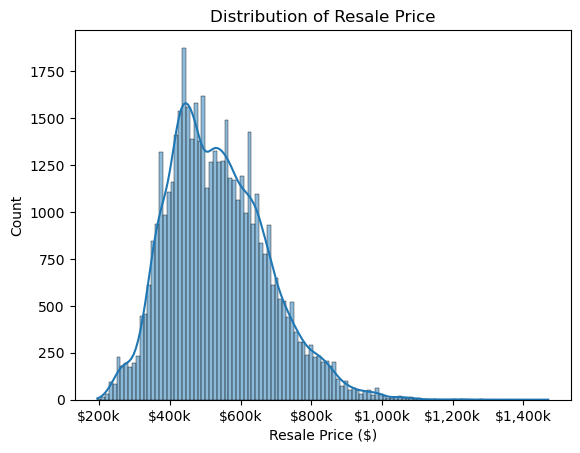

In [56]:
## Understanding distribution of target
# Target = resale_price. A histogram shows its shape (e.g. skew, common price range).
sns.histplot(df['resale_price'], kde=True)
plt.title('Distribution of Resale Price')
plt.xlabel('Resale Price ($)')
plt.ylabel('Count')
plt.gca().xaxis.set_major_formatter(price_axis)
plt.show()


**Distribution of resale price (target)**

- Prices range **$195k to $1.47M**, with the mean **$536k** slightly above the median **$520k**, so the distribution is **mildly right-skewed** (skew ~ 0.59): a small number of expensive flats pull the average up.
- Only **0.9%** of flats (441 rows) fall outside the IQR outlier range, so there are **very few extreme outliers**.

**Implications for modelling:**
- The skew is mild, so tree-based models handle it well as-is; no log transform needed.
- With so few extreme outliers there is not strong reason to keep an error metric that penalises more for large misses.So this points more towards the side of using MAE decided in the next sections.

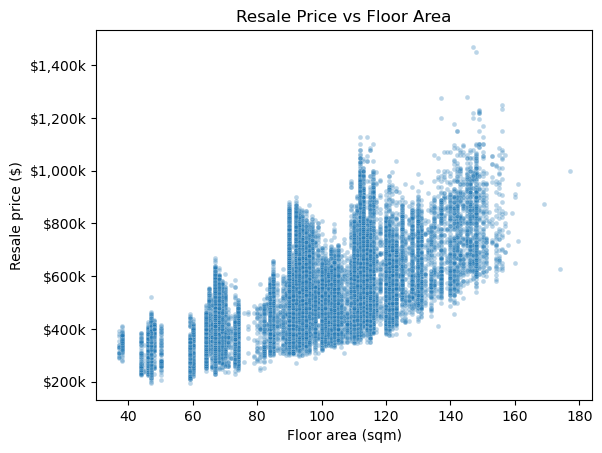

In [57]:
## Scatter plot of floor area vs resale price
# alpha/s keep 47,864 overlapping points readable -- at full opacity the cloud
# turns into a solid block and the trend disappears.
sns.scatterplot(x='floor_area_sqm', y='resale_price', data=df, alpha=0.3, s=12)
plt.title('Resale Price vs Floor Area')
plt.xlabel('Floor area (sqm)')
plt.ylabel('Resale price ($)')
plt.gca().yaxis.set_major_formatter(price_axis)    
plt.show()


### 2.3.1.2 Understanding distribution of features

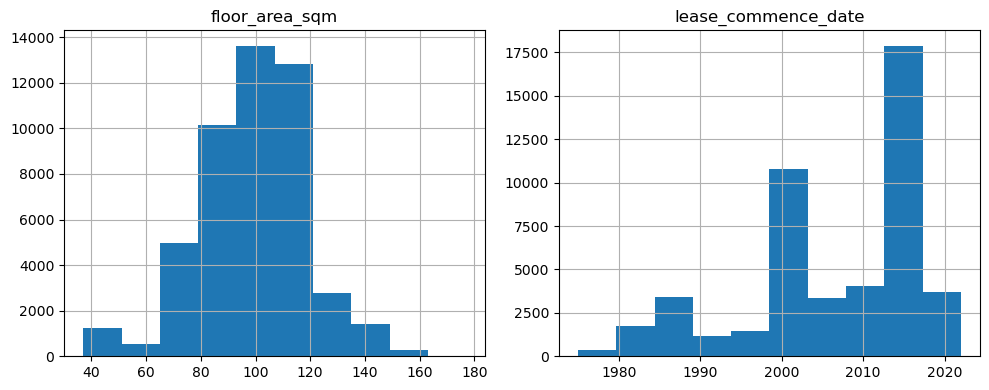

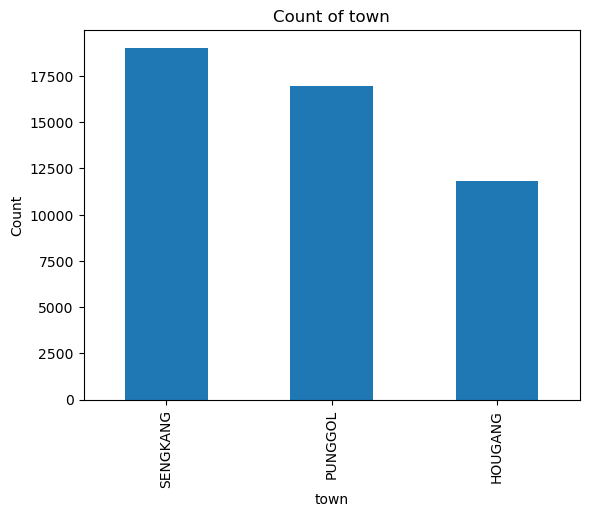

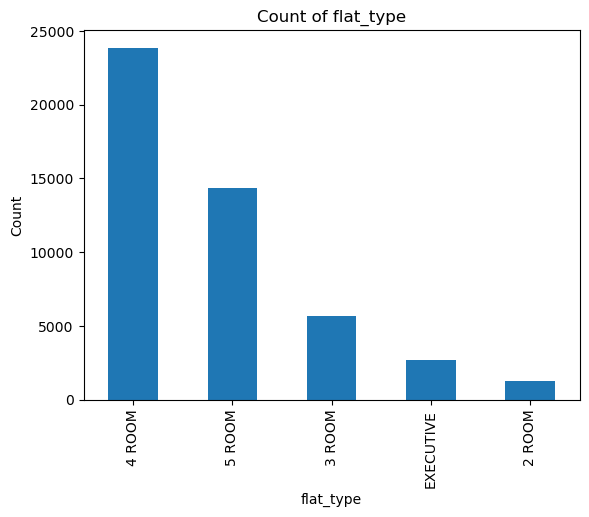

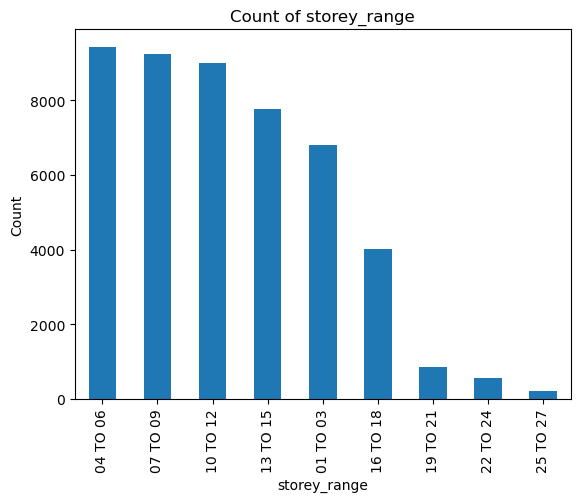

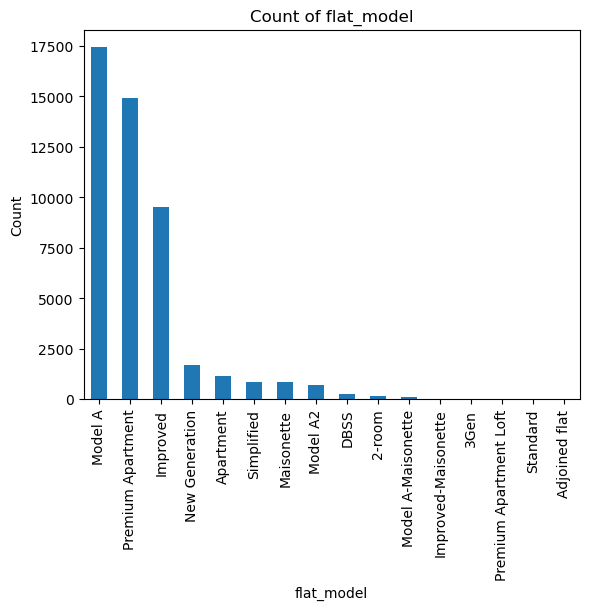

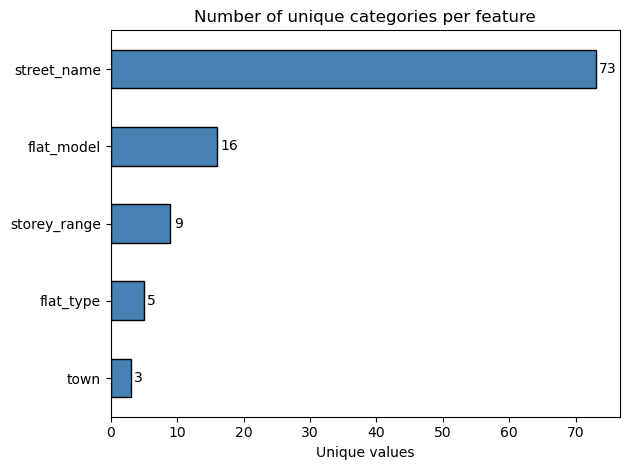

In [58]:
# numeric features: histogram of each
df[['floor_area_sqm', 'lease_commence_date']].hist(figsize=(10, 4))
plt.tight_layout()
plt.show()

# categorical features: count of each category
categorical_cols = ['town', 'flat_type', 'storey_range', 'flat_model']
for col in categorical_cols:
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

# How many categories each categorical column has. This decides whether one-hot
# encoding is cheap (town, flat_type) or expensive (street_name at 73 columns).
cat_cols = ['town', 'flat_type', 'storey_range', 'flat_model', 'street_name']
cardinality = df[cat_cols].nunique().sort_values()

ax = cardinality.plot(kind='barh', color='steelblue', edgecolor='black')
ax.set_title('Number of unique categories per feature')
ax.set_xlabel('Unique values')
for i, v in enumerate(cardinality):          # label each bar with its count
    ax.text(v + 0.5, i, str(v), va='center')
plt.tight_layout()
plt.show()


**Distribution of features**

- **Numeric features (`df.hist`):** `floor_area_sqm` clusters around common HDB
  sizes, and `lease_commence_date` leans toward newer flats.
- **Town** is fairly balanced across the three estates — Sengkang (19,037),
  Punggol (16,983), Hougang (11,844) — so no town dominates the sample.
- **Flat type is imbalanced:** 4-ROOM (23,861, ~50%) and 5-ROOM (14,340, ~30%)
  dominate, while 2-ROOM (1,258) and EXECUTIVE (2,702) are rare.
- **Storey range** concentrates in the low-to-mid floors (04–15 hold most sales)
  and tapers off for higher floors.
- **Flat model** has 16 categories but is dominated by a few — Model A (17,439),
  Premium Apartment (14,937), Improved (9,533); 6 of the 16 models have <100 rows
  and were grouped into "Other" during cleaning.

**Implications for modelling:**
- One-hot encoding suits the low-cardinality categoricals (town, flat_type).
- The flat-type and flat-model imbalance means overall test error is driven
  mostly by the common types (4/5-ROOM, Model A / Premium Apartment).
- Grouping rare flat models avoids near-empty one-hot columns that add noise
  without signal.
- street_name and flat_model have many categories, street_name 73 and flat_model 16 so one hot encoding would add many sparse columns.Need to tweak to either combine as others or drop in feature selection further down.


### 2.3.2 Understanding relationship between variables

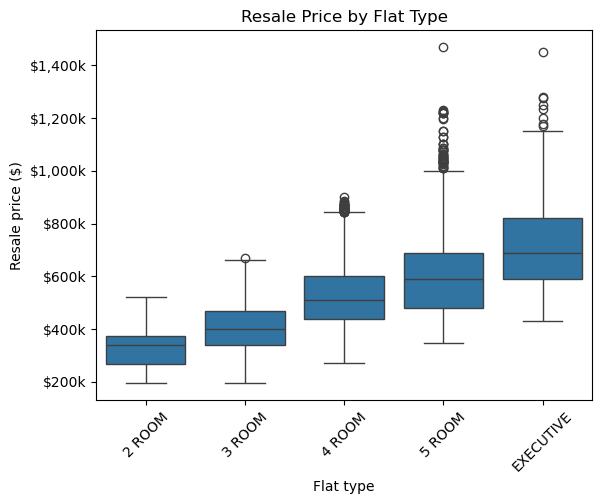

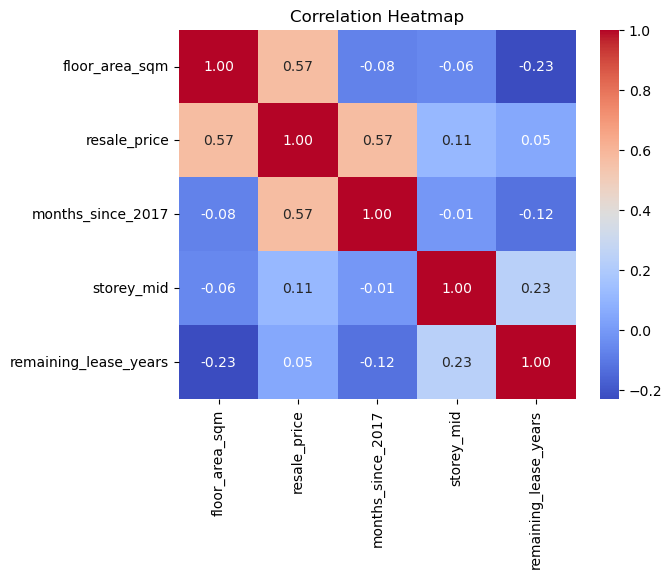

In [59]:
# Categorical feature vs target: price spread per flat type
sns.boxplot(data=df, x='flat_type', y='resale_price')
plt.title('Resale Price by Flat Type')
plt.xlabel('Flat type')
plt.ylabel('Resale price ($)')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(price_axis)
plt.show()

# Correlation heatmap between the numeric columns. The raw file stores month, storey_range and remaining_lease
# as text, so derive the numeric versions here for this plot. Section 3.1 does the
# same conversions properly for modelling.
def parse_lease_years(text):
    parts = text.split()
    return int(parts[0]) + (int(parts[2]) / 12 if len(parts) > 2 else 0)

eda = df[['floor_area_sqm', 'resale_price']].copy()
sale_date = pd.to_datetime(df['month'])
eda['months_since_2017'] = (sale_date.dt.year - 2017) * 12 + (sale_date.dt.month - 1)
eda['storey_mid'] = df['storey_range'].str.split(' TO ').apply(lambda x: (int(x[0]) + int(x[1])) / 2)
eda['remaining_lease_years'] = df['remaining_lease'].apply(parse_lease_years)

sns.heatmap(eda.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

**Relationships with resale price**

- **Correlation heatmap:** `floor_area_sqm` (0.57) and `months_since_2017` (0.57)
  are the strongest numeric drivers; `storey_mid` (0.11) is weak and
  `remaining_lease_years` (0.05) is very weak — the latter because these young
  estates all have long, similar leases with little variation.
- **Floor area vs price (scatter):** a clear positive trend — larger flats cost
  more, matching the 0.57 correlation.
- **Price by flat type (boxplot):** medians rise cleanly from 2-ROOM ($338k) to
  EXECUTIVE ($690k), so flat type is a strong, almost ordinal price driver.
- **Town** has only a modest effect (Hougang $497k → Punggol $530k, ~$33k spread).

**Implications for modelling:**
- Expect `floor_area_sqm`, `flat_type`, and `months_since_2017` to dominate
  feature importance.
- `remaining_lease_years`, `storey`, and `town` are weak predictors — good
  candidates to test dropping in the feature-selection experiments.



# 3. Data Preparation

## 3.1 Data Cleaning

In [ ]:
## Clean data
# df is already filtered to our chosen towns at load time (section 2.1)
df_clean = df.copy()

# 'remaining_lease' is text like "61 years 04 months" -> convert to a numeric value in years
def parse_lease(text):
    parts = text.split()
    years = months = 0
    for i, p in enumerate(parts):
        if p.startswith('year'):
            years = int(parts[i - 1])
        elif p.startswith('month'):
            months = int(parts[i - 1])
    return years + months / 12

df_clean['remaining_lease_years'] = df_clean['remaining_lease'].apply(parse_lease)

# 'month' is text like "2017-01" -> months elapsed since the start of the data.
# Prices rose ~50% over this period, and a plain year number would lose the
# movement within each year.
sale_date = pd.to_datetime(df_clean['month'])
df_clean['months_since_2017'] = (sale_date.dt.year - 2017) * 12 + (sale_date.dt.month - 1)

# 'storey_range' is text like "10 TO 12" -> take the middle floor as a number.
# One-hot encoding would lose the fact that higher floors are higher.
df_clean['storey_mid'] = (
    df_clean['storey_range']
    .str.split(' TO ')
    .apply(lambda x: (int(x[0]) + int(x[1])) / 2)
)

# 'flat_model' has one inconsistently-cased value, plus a few categories with
# too few rows to learn from -> group those into 'Other' (6 categories, 198 rows)
df_clean['flat_model'] = df_clean['flat_model'].replace({'2-room': '2-Room'})
model_counts = df_clean['flat_model'].value_counts()
rare_models = model_counts[model_counts < 100].index
df_clean['flat_model'] = df_clean['flat_model'].where(
    ~df_clean['flat_model'].isin(rare_models), 'Other'  
)

# Drop columns we won't use as features:
#  - month / remaining_lease / storey_range: replaced by the numeric versions above 
#  - block: 1430 unique values, and the number alone means nothing across streets and is more of an id
#  - lease_commence_date: = 99 - (sale date - remaining_lease_years), so the two
#    columns above already contain it
df_clean = df_clean.drop(columns=[
    'month', 'remaining_lease', 'storey_range', 'block', 'lease_commence_date'
])

df_clean.head()


,town,flat_type,street_name,floor_area_sqm,flat_model,resale_price,remaining_lease_years,months_since_2017,storey_mid
0,HOUGANG,2 ROOM,BUANGKOK CRES,47.0,Model A,252000.0,94.333333,0,11.0
1,HOUGANG,3 ROOM,HOUGANG AVE 3,73.0,New Generation,260000.0,60.333333,0,2.0
2,HOUGANG,3 ROOM,HOUGANG AVE 8,60.0,Improved,268000.0,69.000000,0,2.0
3,HOUGANG,3 ROOM,HOUGANG AVE 3,67.0,New Generation,269000.0,60.416667,0,2.0
4,HOUGANG,3 ROOM,HOUGANG AVE 1,67.0,New Generation,270000.0,66.250000,0,2.0


## 3.2 Train-Test Split

In [61]:
## Split data into train set and test set
from sklearn.model_selection import train_test_split

#seperate target variable from features
X = df_clean.drop(columns=['resale_price'])
y = df_clean['resale_price']

# One-hot encode the categorical columns
X = pd.get_dummies(X, columns=['town', 'flat_type', 'street_name', 'flat_model'])

# Save the column list 
model_columns = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (38291, 96) | Test: (9573, 96)


I left my train and test 80/20 because i have sufficient amounts of data at 47k rows 

## 3.3 Assumptions and limitations

Scope:

The model covers  Punggol, Sengkang and Hougang only , for sale dates from
Jan 2017 to Jul 2026 . Tree models cannot extrapolate past the last period
they were trained on, so asking for a later date returns the value learned for
Jul 2026 rather than a projected price.Linear regression can move and extrapolate
but it may just be nonsense.

Feature construction 
Storey:  HDB publishes a 3-floor band rather than the exact floor, so each
flat is assumed to sit at the  midpoint  of its band ( 10 TO 12  → 11). An
individual flat may be one floor out, but the error is symmetric and averages
out across 47,864 rows. The band is kept as a  number rather than nine
one-hot columns , so the model knows a higher band means a higher floor: one
split can separate low floors from high, and rarely-sold high bands inherit
the general trend instead of being learned in isolation. This assumes price
moves consistently in one direction with height, which holds for HDB flats
(view, noise, height premium).

Remaining lease  is adjusted to fractional years ( 61 years 04 months --> 61.33).
Sale month  is encoded as an ordered count of months since Jan 2017, so
2017-01 is 0, 2017-02 is 1, 2018-01 is 12, and so on up to 114 for 2026-07.
It does not assume prices rise at a constant rate.

Cleaning 
Rare flat models grouped:  6 of the 16 flat models have fewer than 100 rows
(198 rows, 0.41% of the data). Their  flat_model  label becomes  Other ; no
rows are dropped and no other value is altered. With so few examples each, the
model could not learn a reliable effect for them individually, so one pooled
category is preferable to six unreliable ones. The cost is that  Other  mixes
genuinely different flat types together.
Within  flat_model ,  2-room  and  2-Room  are assumed to be the same category,
differing only by a casing error. (This is the flat *model* named "2-room",
which is separate from the  flat_type  value "2 ROOM" recording size.)
 lease_commence_date  dropped  as redundant  , it is recoverable from the sale
date and the remaining lease, both of which are kept.
 block  dropped**  , with 1,430 unique values, a block number carries no
meaning that transfers across different streets and is more of an ID.


# 4. Modelling

I use MAE to choose the model.

MAE is in dollars. It answers what a buyer or seller actually asks: "how far off is this estimate?" An MAE of $20,000 means the prediction is typically $20,000 away from the real price. RMSE is not in plain dollars, so it is not something I can show a user.
RMSE punishes big mistakes much harder than small ones. That is the right choice when one large error is a disaster. A price estimate is not like that , being $50k off once is not worse than being $10k off five times.
My EDA found only 0.9% outliers, so there are very few extreme prices needing that harder punishment.
I still report RMSE and R² for every model, but they do not decide:

RMSE is a warning sign. If it is much higher than MAE, the model is making a few very large mistakes.
R² is a quick overall check of fit. It shows how much of the price difference between flats the model captures (0.97 = 97%).

MSE is not considered beacuse it is in squared dollars which heavily inflates the error value to hundreds of millions, this negatively impacts the user interperability and in the dataset there is no number remotely close to this

Lets say for this model to be accurate i set a threshold of 5% of a typical $520K flat which is about $26,000 which is what will be the bar the model should be able to overcome.

### 4.1 Train Model

In [62]:
## Initialise and train model
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import RandomizedSearchCV


models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
    
}
    
for name, model in models.items():
    model.fit(X_train, y_train)
    print('trained', name)
    


trained Linear Regression
trained Decision Tree
trained Random Forest
trained Gradient Boosting


# 5. Model Evaluation

In [63]:
## Model evaluation
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error 

table_rows = []
for name, model in models.items():
    trp = model.predict(X_train)
    tep = model.predict(X_test)
    table_rows.append({
        'Model': name,
        'Train R2': round(r2_score(y_train, trp), 4),
        'Test R2':  round(r2_score(y_test,  tep), 4),
        'Train MAE': mean_absolute_error(y_train, trp),
        'Test MAE':  mean_absolute_error(y_test,  tep),
        'Train RMSE': root_mean_squared_error(y_train, trp),
        'Test RMSE': root_mean_squared_error(y_test, tep),
        'MAE_gap': abs(mean_absolute_error(y_test, tep) - mean_absolute_error(y_train, trp))
    })


results_table = pd.DataFrame(table_rows).set_index('Model')
results_table.style.format({
    'Train R2': '{:.4f}', 'Test R2': '{:.4f}',
    'Train MAE': '${:,.0f}', 'Test MAE': '${:,.0f}', 'Train RMSE': '${:,.0f}', 'Test RMSE': '${:,.0f}', 'MAE_gap': '${:,.0f}'
})


,Train R2,Test R2,Train MAE,Test MAE,Train RMSE,Test RMSE,MAE_gap
Model,,,,,,,
Linear Regression,0.8964,0.8971,"$35,226","$35,107","$45,484","$45,606",$118
Decision Tree,0.9991,0.9415,$928,"$24,570","$4,178","$34,383","$23,641"
Random Forest,0.9947,0.9665,"$7,378","$18,837","$10,323","$26,018","$11,458"
Gradient Boosting,0.9297,0.9293,"$28,324","$28,660","$37,473","$37,803",$336


## 5.1 Interpreting the metrics on the baselines

MAE separates the four baselines cleanly, from $18,837 to $35,107 — a $16k spread, so it discriminates well between models.

Two checks confirm the reasoning in Section 4. RMSE sits between 1.30× and 1.40× MAE for every model, so errors are fairly uniform and none of them hides a tail of catastrophic misses , MAE is safe to decide on.

R² all relatively high but it makes them seem more similar than they are , Decision Tree (0.9415) , Random Forest (0.9665) , Linear Regression (0.8964) , Gradient Boosting (0.9297).We have to be cautious using R² because, when we look at an example like RF , very very similar R²  value at (0.9947) for Train and (0.9665) for Test, but it dosent show the aforementioned gap between the train test MAE.

## 5.2 Model comparison and selection rationale

Linear regression model is underfitting and has the worst performance among the models. It is not able to capture the complex relationships in the data due to its simplicity, leading to lower R2 and higher error metrics.It does so as it applied one fixed coeffiecient regardless of town or year, one square metre is not the same in hougang and punggol and not the same in 2017 and 2026 thus, both train and test MAE remain at around $35k.Its MAE_gap is  $118 which means that more data would not help.

Decision tree is a single tree so nothing can fix its mistakes and it continues splitting until leaves hold indivual flats producing the largest gap of $23,641 between test and train showing that its overfitting and also memorising.

Random forest MAE_gap is $11,458 , this shows that  Random forest overfitting.However it is different from decision tree it averages 100 such trees which helps to half the memorisation.
Random forest is the strongest baseline model when we purely look at the test MAE at $18,837, so i did consider it.However as aforementioned it is memorising its train MAE of $7,378 is 2.6x lower than the test.If i were to tune it  then i would have a to limit tree depth which would remove the very thing that is causing the lower errors.

Gradient boosting is the second weakest model at $28,660 Test MAE and is underfitting at a MAE_gap of $336.The model underfitting means that it has too little capacity as the values right now are small 100 shallow trees at depth 3 which we can tweak in the next few steps by adding more trees , greater depth and learning rate.GB trees are also depth limited whereas random forests 100 unconstrained trees would be more taxing during deployment for less or no gain.Thus for this use case i will instead go forward with gradient boosting.

# 6. Iterative Model Development

## 6.1 Feature importance

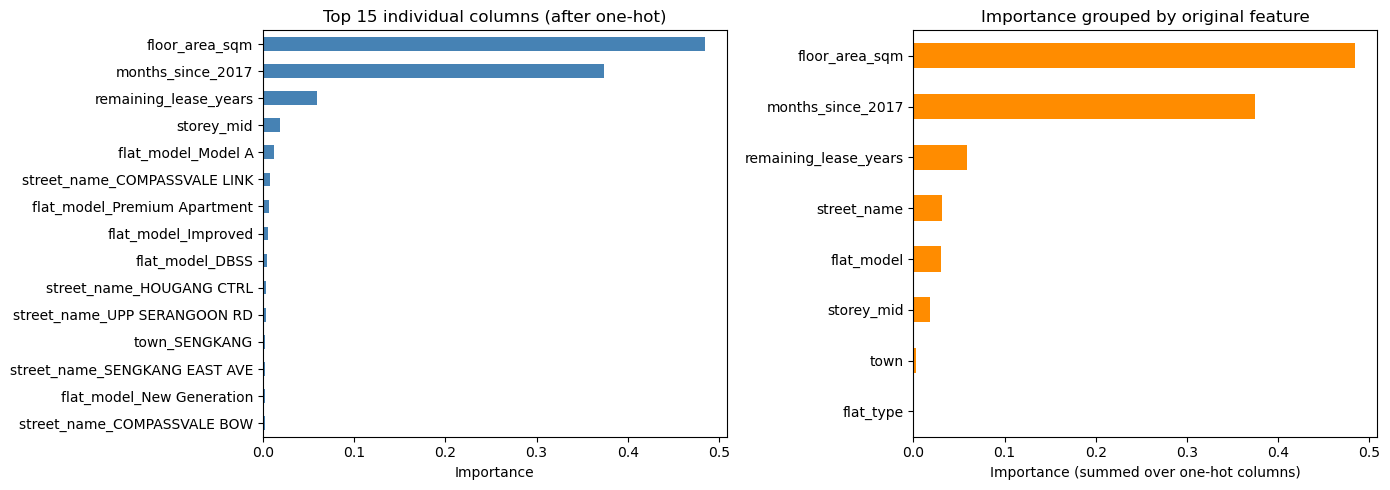

floor_area_sqm           0.4842
months_since_2017        0.3742
remaining_lease_years    0.0586
street_name              0.0308
flat_model               0.0305
storey_mid               0.0185
town                     0.0025
flat_type                0.0007


In [64]:
## Feature importance from the baseline Gradient Boosting model.
## Used to decide which features are worth keeping before any tuning.
gb_base = models['Gradient Boosting']      # already fitted on X_train in Section 4
importances = pd.Series(gb_base.feature_importances_, index=X_train.columns)

# One-hot encoding split 4 categorical columns into 96. Judged individually every
# street_name dummy looks negligible, so also group them back to the original
# feature -- that is the view that actually answers "can anything be dropped".
def original_feature(col):
    for prefix in ['town_', 'flat_type_', 'street_name_', 'flat_model_']:
        if col.startswith(prefix):
            return prefix.rstrip('_')
    return col

grouped = importances.groupby(original_feature).sum().sort_values()
top15 = importances.sort_values().tail(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top15.plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 individual columns (after one-hot)')
axes[0].set_xlabel('Importance')

grouped.plot.barh(ax=axes[1], color='darkorange')
axes[1].set_title('Importance grouped by original feature')
axes[1].set_xlabel('Importance (summed over one-hot columns)')

plt.tight_layout()
plt.show()

print(grouped.sort_values(ascending=False).round(4).to_string())


What the model actually uses. floor_area_sqm (~0.48) and months_since_2017 (~0.38) dominate, together accounting for roughly 86% of total importance — size and sale timing explain most of the price. This matches the EDA, where both had the strongest correlation with price (0.57 each).

The lower half is more informative. town scores below street_name not because location is unimportant, but because street_name already contains it , every street sits in exactly one town. This suggests town may be redundant. If that is true, street_name should be far more costly to remove than town; both are tested in 6.2.

flat_type is lowest of all, despite the EDA showing medians rising from 2-ROOM ($338k) to EXECUTIVE ($690k). Again redundancy: floor_area_sqm captures flat size more precisely, so flat_type adds little once floor area is available.

remaining_lease_years is third highest, which contradicts its weak correlation with price (0.05) in the EDA. Correlation measures only a linear relationship, while the tree can use the feature non-linearly and in combination with others — a reminder that low correlation does not mean low usefulness.

Implication: flat_type, town and storey_mid are the candidates to test dropping. But low importance here signals redundancy rather than uselessness, so each is tested with cross-validation in 6.2 rather than removed on the strength of this plot alone

## 6.2 Feature selection

In [65]:
## 6.2 Feature selection: test dropping the low-importance features from 6.1.
## The importance plot only suggests candidates -- each one is confirmed with
## 5-fold CV on the training set, so the test set stays untouched.
from sklearn.model_selection import cross_val_score
# 1. Spell out exactly which columns belong to each candidate 
# get_dummies replaced the categorical columns with prefixed ones, while the
# numeric columns kept their original name.
flat_type_cols = [c for c in X_train.columns if c.startswith('flat_type_')]
town_cols      = [c for c in X_train.columns if c.startswith('town_')]
storey_cols    = ['storey_mid']
## print to make it easier to view and keep track of which columns are being dropped in each experiment
print('flat_type  ->', flat_type_cols)
print('town       ->', town_cols)
print('storey_mid ->', storey_cols)
print()

# --- 2. Define the experiments 
experiments = {
    'Drop flat_type':        flat_type_cols,
    'Drop town':             town_cols,
    'Drop storey_mid':       storey_cols,
    'Drop flat_type + town': flat_type_cols + town_cols,   # redundancy can be joint so we test for that too
}

#  3. Score every feature set with the SAME model 
gb = GradientBoostingRegressor(random_state=42)   # held constant: only features change

def cv_mae(X):
    """Average MAE across 5 folds of the training set."""
    return -cross_val_score(gb, X, y_train, cv=5,
                            scoring='neg_mean_absolute_error').mean()

baseline = cv_mae(X_train)
print(f'{"All features (baseline)":<24} CV MAE = ${baseline:>7,.0f}   {X_train.shape[1]} cols')

for label, drop_cols in experiments.items():
    Xs      = X_train.drop(columns=drop_cols)
    mae     = cv_mae(Xs)
    diff    = mae - baseline
    verdict = 'worse' if diff > 0 else 'better'
    print(f'{label:<24} CV MAE = ${mae:>7,.0f}   {Xs.shape[1]} cols   '
          f'({verdict} by ${abs(diff):,.0f}, -{len(drop_cols)} cols)')



flat_type  -> ['flat_type_2 ROOM', 'flat_type_3 ROOM', 'flat_type_4 ROOM', 'flat_type_5 ROOM', 'flat_type_EXECUTIVE']
town       -> ['town_HOUGANG', 'town_PUNGGOL', 'town_SENGKANG']
storey_mid -> ['storey_mid']

All features (baseline)  CV MAE = $ 28,745   96 cols
Drop flat_type           CV MAE = $ 28,727   91 cols   (better by $18, -5 cols)
Drop town                CV MAE = $ 29,026   93 cols   (worse by $281, -3 cols)
Drop storey_mid          CV MAE = $ 31,923   95 cols   (worse by $3,178, -1 cols)
Drop flat_type + town    CV MAE = $ 29,045   88 cols   (worse by $299, -8 cols)


6.2 Feature selection — testing the low-importance candidates. The importance plot suggested flat_type, town and storey_mid as drop candidates. Each was tested with 5-fold CV on the training set, one at a time, with the default GB held constant so only the feature set changes.

Decision: keep all features.


storey_mid is the clearest result. It ranked 6th of 8 on importance, yet removing it costs $3,178 ,the largest penalty of any drop which i would not say is unexepected seeing as it had a sizable importance.
A low importance score does not mean a feature can be dropped, storey is the only column encoding height, so nothing else can substitute for it. Importance measures how often a feature is used in splits, not whether its information exists elsewhere.

flat_type is genuinely redundant. Removing its 5 columns changes CV MAE by $18 — 0.06% of baseline, within cross-validation noise. floor_area_sqm carries the same size information more precisely.

town is less redundant than the plot suggested with only a sliver of importance at 0.0025 but costing $281 to remove. street_name implies the town, but at the default depth of 3 a tree has at most 8 leaves and cannot afford to spend splits isolating individual streets from 73 one-hot columns. town partitions the data geographically in a single split, giving the shallow baseline trees a cheap approximation of location.

Removing both redundant categoricals together costs $299,essentially the town penalty alone, confirming flat_type contributes little either way so no joint here like we were curious about before the testing.

flat_type is the only feature droppable at no cost, but it is retained: the $18 difference is noise, and it is required to derive rooms for the engineered area_per_room feature in 6.3, so it must remain an input regardless

In [66]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)
street_cols = [c for c in X_train.columns if c.startswith('street_name_')]
##test the effect of dropping street_name features on model performance
experiments_streets = {
    'All features (baseline)': X_train,
    'Drop street_name (73 cols)': X_train.drop(columns=street_cols),
}

for name, Xset in experiments_streets.items():
    mae = -cross_val_score(gb, Xset, y_train, cv=5,
                           scoring='neg_mean_absolute_error').mean()
    print(f'{name:<28} CV MAE = ${mae:,.0f}  ({Xset.shape[1]} features)')


All features (baseline)      CV MAE = $28,745  (96 features)
Drop street_name (73 cols)   CV MAE = $30,225  (23 features)




Feature selection, so should we drop street_name?

`street_name` is high-cardinality (73 one-hot columns). I tested removing it,
scoring with 5-fold CV on the training set (default GB). CV MAE rose from
$28,745 to $30,225 (+$1,480), so `street_name` carries useful location signal
and is kept.



## 6.3 Feature engineering

In [67]:
## Feature engineering experiment: area_per_room = floor_area_sqm / rooms
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor

# rooms from flat_type; EXECUTIVE assumed = 6 (larger than 5-ROOM)  [ASSUMPTION]
rooms = df_clean['flat_type'].map(
    {'2 ROOM': 2, '3 ROOM': 3, '4 ROOM': 4, '5 ROOM': 5, 'EXECUTIVE': 6})

# rebuild X with the new feature, using the SAME split (random_state=42) so rows line up
X_fe = df_clean.drop(columns=['resale_price']).copy()
X_fe['area_per_room'] = df_clean['floor_area_sqm'] / rooms
X_fe = pd.get_dummies(X_fe, columns=['town', 'flat_type', 'street_name', 'flat_model'])
X_fe_train, X_fe_test = train_test_split(X_fe, test_size=0.2, random_state=42)

gb = GradientBoostingRegressor(random_state=42)
base = -cross_val_score(gb, X_train,    y_train, cv=5, scoring='neg_mean_absolute_error').mean()
new  = -cross_val_score(gb, X_fe_train, y_train, cv=5, scoring='neg_mean_absolute_error').mean()
print(f'Baseline (no area_per_room): ${base:,.0f}  ({X_train.shape[1]} features)')
print(f'With area_per_room:          ${new:,.0f}  ({X_fe_train.shape[1]} features)')

Baseline (no area_per_room): $28,745  (96 features)
With area_per_room:          $27,992  (97 features)


**Feature engineering — `area_per_room`**
Engineered `area_per_room = floor_area_sqm / rooms` (rooms from flat_type;
EXECUTIVE assumed = 6). 5-fold CV on the training set (default GB) improved MAE
from $28,745 to $27,992 (−$753).Not a super meaningful gain but still a gain so i kept in the final feature set.
Down the road the when i tune the model to have more trees it might approximate the ratio better but the gain never goes negative so we are gonna continue using it so that the tuned model is trained with the features.


## 6.4 Hyperparameter tuning

In [68]:
## Hyperparameter tuning: Gradient Boosting via RandomizedSearchCV (final feature set, incl. area_per_room)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

# max 3 values per hyperparameter (spec rule). These target GB's underfitting:
# more trees (n_estimators), deeper trees (max_depth), and a range of learning rates.
param_dist = {
    'n_estimators':  [200, 400, 600], ##add more capacity beacuse the model was underfitting,baseline was 100 so we up it to 200,400,600
    'learning_rate': [0.05, 0.1, 0.2], ## balance with n_estimators, 0.1 is the default, 0.05 is slower but more accurate, 0.2 is faster but less accurate
    'max_depth':     [3, 4, 5], ##make deeper,baseline was too shallow so cant capture interactions probably why creating area_per_room helped
}

search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=10, cv=5,
    scoring='neg_mean_absolute_error',
    random_state=42, n_jobs=-1, verbose=1,
)
search.fit(X_fe_train, y_train)

best_gb = search.best_estimator_
print('Best params:', search.best_params_)
print(f'Best CV MAE : ${-search.best_score_:,.0f}')
print()

# Final evaluation on the held-out TEST set (touched once, here)
for label, Xs, ys in [('Train', X_fe_train, y_train), ('Test', X_fe_test, y_test)]:
    pred = best_gb.predict(Xs)
    print(f'{label:5} R2={r2_score(ys, pred):.4f}  '
          f'MAE=${mean_absolute_error(ys, pred):,.0f}  '
          f'RMSE=${root_mean_squared_error(ys, pred):,.0f}')

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'n_estimators': 600, 'max_depth': 5, 'learning_rate': 0.1}
Best CV MAE : $17,869

Train R2=0.9782  MAE=$15,659  RMSE=$20,861
Test  R2=0.9721  MAE=$17,539  RMSE=$23,761


See how best params are top of range,like n_estimators 600 and max_depth 5 maybe we can make it even better by providing more capacity let me try that in the below cells

In [69]:
## Refined tuning: previous winners hit the ceiling (n_estimators=600, max_depth=5),
## so search higher. Still 3 values per hyperparameter (spec rule).
param_dist_2 = {
    'n_estimators':  [600, 800, 1000],
    'max_depth':     [5, 6, 7],
    'learning_rate': [0.05, 0.1, 0.15],
}

search2 = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_distributions=param_dist_2,
    n_iter=10, cv=5,
    scoring='neg_mean_absolute_error',
    random_state=42, n_jobs=-1, verbose=1,
)
search2.fit(X_fe_train, y_train)

best_gb2 = search2.best_estimator_
print('Refined best params:', search2.best_params_)
print(f'Refined best CV MAE: ${-search2.best_score_:,.0f}')
print()

for label, Xs, ys in [('Train', X_fe_train, y_train), ('Test', X_fe_test, y_test)]:
    pred = best_gb2.predict(Xs)
    print(f'{label:5} R2={r2_score(ys, pred):.4f}  '
          f'MAE=${mean_absolute_error(ys, pred):,.0f}  '
          f'RMSE=${root_mean_squared_error(ys, pred):,.0f}')

# Decision rule: adopt this only if Test MAE beats $17,539 AND the train->test gap
# stays small. If the gap widens (overfitting) or MAE stalls, keep the first model.

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Refined best params: {'n_estimators': 800, 'max_depth': 6, 'learning_rate': 0.1}
Refined best CV MAE: $17,445

Train R2=0.9843  MAE=$13,248  RMSE=$17,699
Test  R2=0.9731  MAE=$17,079  RMSE=$23,326


So after extending to search more Test MAE only improved $460 while while train test gap around doubled from 1.8k to 3.8k, the model is starting to overfit and it also took a rather long time.So I am going to stick with the first iteration as it looks like a more optimal position.

## 6.5 Tuning summary

| Stage | Params | CV MAE | Test MAE | Test R² | Train→Test MAE_gap |
|---|---|---|---|---|---|
| GB baseline | defaults (100 / 3 / 0.1) | — | $28,660 | 0.9293 | $336 |
| RF baseline (best baseline) | 100 trees, unlimited depth | — | $18,837 | 0.9665 | $11,459 |
| GB tuned r1  | 600 / 5 / 0.1 | $17,869 | $17,539 | 0.9721 | $1,880 |
| GB tuned r2 (rejected) | 800 / 6 / 0.1 | $17,445 | $17,079 | 0.9732 | $3,831 |

Tuning moved Gradient Boosting from the second-worst baseline ($28,660) to the
best model overall ($17,539) , an improvement of $11,121. It also overtook
Random Forest's $18,837 while holding a train–test gap of $1,880 against RF's
$11,459, so the gain did not come from memorising the training set.

Why round 1 was chosen despite round 2's lower MAE.Round 2 improves test MAE
by $460 (2.6%), but its train–test gap doubles from $1,880 to $3,831, meaning the
extra capacity is increasingly fitting training noise rather than signal. The
trend is the concern: pushing capacity further would keep trading generalisation
for a shrinking gain. Round 2 is also 33% more trees at 20% greater depth,
producing a larger and slower model for a 2.6% improvement.Round 1 is therefore selected despite round 2 winning on three of the four columns — round 2's CV MAE is $424 lower, its test MAE $460 lower, and its R² marginally higher.Round 1 test is $1,880 above train which is slightly higher
than the $336 of the baseline model which was underfitting, the new gap of test and train
MAE is modest and relatively small compared to the RF baselines at 12% above against Random forest's 155%.


All searches use RandomizedSearchCV with random_state=42, cv=5, and at most
3 values per hyperparameter, so the results are reproducible.


# 7. Final Model & Deployment

Final model against the business goal. The tuned Gradient Boosting model reaches $17,539 MAE, about 3.4% of the $520k median flat, improving on the best baseline (RF, $18,837) by $1,298. An error this size is accurate enough to set an asking price or sanity-check a listing, though not a substitute for a formal valuation. The RMSE/MAE ratio stays low at 1.35, so the improvement did not come at the cost of occasional large errors.


## 7.1 Save the trained model

In [70]:
import joblib

# best_gb = your final tuned model (600 / 5 / 0.1) from 6.4 round 1
joblib.dump(best_gb, 'resale_price_model.pkl')     # the trained model
joblib.dump(list(X_fe.columns), 'model_columns.pkl')  # the 97 feature columns, in order

print('Saved:', best_gb.n_estimators, 'trees |', len(X_fe.columns), 'columns')


Saved: 600 trees | 97 columns


## 7.2 Predict on new data

In [71]:
## New data
import joblib

# load exactly what the app will load (this also verifies your .pkl files work)
saved_model   = joblib.load('resale_price_model.pkl')
saved_columns = joblib.load('model_columns.pkl')

# one new flat to price
new_flat = pd.DataFrame([{
    'town': 'PUNGGOL',
    'flat_type': '4 ROOM',
    'street_name': 'PUNGGOL DR',
    'floor_area_sqm': 93.0,
    'flat_model': 'Model A',
    'remaining_lease_years': 90.0,
    'months_since_2017': 108,
    'storey_mid': 11.0,
}])

# IMPORTANT: rebuild the SAME feature the model was trained on.
# area_per_room = floor_area_sqm / rooms (rooms from flat_type; EXECUTIVE = 6)
rooms = new_flat['flat_type'].map({'2 ROOM':2,'3 ROOM':3,'4 ROOM':4,'5 ROOM':5,'EXECUTIVE':6})
new_flat['area_per_room'] = new_flat['floor_area_sqm'] / rooms

# one-hot, then line the columns up with the model's training columns.
# reindex fills every column this row does not have with 0, in the right order.
new_flat = pd.get_dummies(new_flat)
new_flat = new_flat.reindex(columns=saved_columns, fill_value=0)

## Predict
print(f'Predicted resale price: ${saved_model.predict(new_flat)[0]:,.0f}')

Predicted resale price: $682,257
